In [1]:
#MakeMore Part3开启！
#这一部分和part2那样新开一个notebook不太一样，andrej会直接在part2的基础上继续添加东西
#直接开始吧

In [2]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline
#环境导入，和之前的环境是一样的，前两行是torch，后两行是画图工具

In [3]:
words=open("names.txt","r").read().splitlines()
words[:3]
#还是一样导入words

['emma', 'olivia', 'ava']

In [4]:
chars=sorted(list(set(''.join(words))))
stoi={s:i+1 for i,s in enumerate(chars)}
stoi['.']=0
itos={i:s for s,i in stoi.items()}
print(itos)
vocab_size=len(itos)
#还是一样建立字符数字表
#只不过直接生成好vocab_size

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [8]:
#构建训练集，验证集，测试集
#直接复制过来就好
block_size=3

def build_dataset(words,block_size):#依据words构建数据集的函数
  X, Y = [], []
  for w in words:

    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)  
      context = context[1:] + [ix] 

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)#打印数据集的大小
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1],block_size)#0%~80%
Xdev, Ydev = build_dataset(words[n1:n2],block_size)#80%~90%
Xte, Yte = build_dataset(words[n2:],block_size)#90~100%

torch.Size([182580, 3]) torch.Size([182580])
torch.Size([22767, 3]) torch.Size([22767])
torch.Size([22799, 3]) torch.Size([22799])


In [9]:
#先生成神经网络
g = torch.Generator().manual_seed(2147483647)

#旋钮
n_embd=10
n_hidden=200

#超参数
C = torch.randn((vocab_size, n_embd), generator=g)#嵌入层
W1 = torch.randn((block_size*n_embd,n_hidden), generator=g)#缩小到200个
b1 = torch.randn(n_hidden,generator=g)#隐藏层
W2 = torch.randn((n_hidden, vocab_size), generator=g)#激活层
b2 = torch.randn(vocab_size, generator=g)#激活层

parameters = [C, W1, b1, W2, b2]#所有的总参数，用于后续的梯度清除
print(f"总参数量：{sum(p.nelement() for p in parameters)}")
for p in parameters:
    p.requires_grad=True

总参数量：11897


In [10]:
#一样复制过来，稍微调整下参数位置就可以了
max_steps=200000
batch_size=32

lossi=[]

#训练
for i in range(max_steps):
    
    #前向传播
    ix=torch.randint(1,Xtr.shape[0],(batch_size,),generator=g)
    Xb,Yb=Xtr[ix],Ytr[ix]
    
    emb = C[Xb]
    embcat=emb.view(batch_size, block_size*n_embd)
    hpreact=embcat@ W1 + b1
    h = torch.tanh(hpreact) # (32, 100)
    logits = h @ W2 + b2 
    loss=F.cross_entropy(logits,Yb)
    
    #清空梯度
    for p in parameters:
        p.grad=None
    
    #反向传播
    loss.backward()

    #更新梯度
    lr=0.1 if i<(max_steps/2) else 0.01
    for p in parameters:
        p.data+=-lr*p.grad

    if i%10000==0:
        print(f"{i:7d}/{max_steps:7d}:{loss.item():.4f}")
    #存储参数
    lossi.append(loss.log10().item())

      0/ 200000:21.3397
  10000/ 200000:2.9612
  20000/ 200000:2.8091
  30000/ 200000:2.3070
  40000/ 200000:2.7541
  50000/ 200000:2.5519
  60000/ 200000:2.2964
  70000/ 200000:2.2251
  80000/ 200000:2.0623
  90000/ 200000:2.4373
 100000/ 200000:2.3082
 110000/ 200000:2.0747
 120000/ 200000:2.1816
 130000/ 200000:2.2747
 140000/ 200000:1.5415
 150000/ 200000:1.9268
 160000/ 200000:2.1260
 170000/ 200000:2.3212
 180000/ 200000:2.1252
 190000/ 200000:1.9200


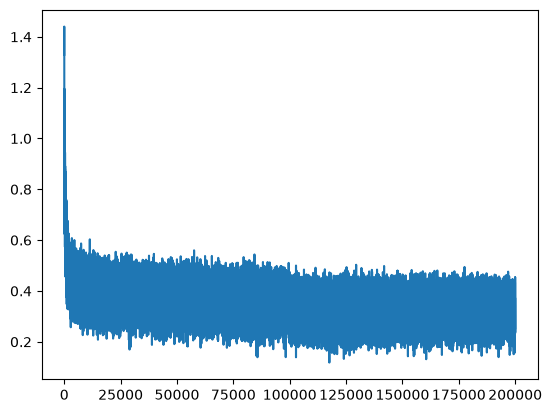

In [11]:
plt.plot(lossi)

In [14]:
@torch.no_grad() #关掉grad,评估的时候不需要反向传播
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]#用传入的split进行查表
    
  emb = C[x] # (N, block_size, n_embd)
  embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  h = torch.tanh(embcat @ W1 + b1) # (N, n_hidden)
  logits = h @ W2 + b2 # (N, vocab_size)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')


train 2.1355013847351074
val 2.1711013317108154


In [18]:
#采样部分，和之前是一样的，只不过我们不用多层神经网络
g = torch.Generator().manual_seed(2147483647+10)#换个种子

for i in range(20):#生成20个名字
    context=[0]*block_size#上下文。由于我们所有名字的开头全部都是一串点，所以我们可以直接用这个
    out=[]#输出

    while True:#用循环来生成姓名，直到出现'.'
        emb = C[torch.tensor([context])] 
        embcat = emb.view(1, -1) 
        h = torch.tanh(embcat @ W1 + b1) 
        logits = h @ W2 + b2 # (N, vocab_size)
        probs=F.softmax(logits,dim=1)#loss的计算用的是cross_entropy，现在用softmax计算probs
        ix=torch.multinomial(probs,num_samples=1,generator=g).item()#根据概率输出词汇
        context=context[1:]+[ix]
        out.append(itos[ix])
        if ix==0:
            break
    print(''.join(s for s in out))

carmahzabelle.
khi.
mili.
taty.
skanden.
jazhien.
delynn.
jarqui.
nellara.
chaiiv.
kaleigh.
ham.
join.
quint.
shon.
walianni.
wazelo.
dearyxi.
jacee.
dus.


In [19]:
#我们现在要改进我们的神经网络
#所以第一步就是：先看看他有什么问题
#首先我们会发现：我们一开始的loss出奇的高
#我们来预估一下如果一个均匀分布的loss是多少
#loss是概率的负对数似然
#所以就是
-torch.tensor(1.0/27.0).log()

tensor(3.2958)

In [20]:
#所以其实我们的loss一开始能到20多是完全没有道理的
#很可能是因为我们的一开始随机出来的参数导致了非常大的偏差